Algorithms to fit Gaussian
==========================

Identical to `fitGaussian.ipynb`, but using an updated GAMPixPy readout simulation:

1. Each waveform has 3 pre-samples prior to the trigger time.
2. The triggered sample has to be above 3&times;50e<sup>-</sup>, and the sum of a readout window (20 ticks) also has to be greater than 3&times;50e<sup>-</sup>.  The previous simulation only requires the sum of the readout window to be greater than 3&times;50e<sup>-</sup>.

Because of 2., the trigger rate is lower in the current sample.

Note that in both the previous and the current simulated samples, the trigger logic uses the true signals.  If the triggered tick happens to have a negative noise value, it will be possible to see a value less than 3&times;50e<sup>-</sup>.

In [1]:
import numpy as np
import pandas as pd
import h5py
import torch

import matplotlib.pyplot as plt

In [2]:
sim_output_path = '/Users/yuntse/data/lartpc_rd/gampix/detsim/radiologicals/gampixpy_fullgeoanatruth-vd-reduced_g4_00_2Mhz_segmentlabel_lowtrig_5mmpitch_presample.h5'

In [3]:
# GAMPixPy outputs
with h5py.File(sim_output_path, 'r') as simf:
    # Print all top-level groups/datasets
    print(list(simf.keys()))
    fT = simf['tiles']
    fP = simf['pixels']
    # fM = simf['meta']
    print(fT.dtype)
    # print(fP.dtype)
    # print(fM.dtype)

    tempT = fT[()]
    tempP = fP[()]
    # tempM = fM[()]

['meta', 'pixels', 'tiles']
[('event id', '<u4'), ('tile trigger id', '<u4'), ('tile tpc', '<u4'), ('tile x', '<f4'), ('tile y', '<f4'), ('trig z', '<f4'), ('trig t', '<f4'), ('start t', '<f4'), ('waveform', '<f4', (20,)), ('raw waveform', '<f4', (20,)), ('attribution', '<f4', (20, 3)), ('label', '<i4', (3,))]


In [4]:
dT = pd.DataFrame({
    name: tempT[name].tolist() if tempT[name].ndim > 1 else tempT[name]
    for name in tempT.dtype.names
})
dT

,event id,tile trigger id,tile tpc,tile x,tile y,trig z,trig t,start t,waveform,raw waveform,attribution,label
0,0,0,0,-1065.0,-575.0,929.928528,5807.936523,5806.436523,"[71.51425170898438, 23.693281173706055, 110.85...","[40.419734954833984, 54.4290771484375, 108.858...","[[1.0, 0.0, 0.0], [0.866381824016571, 0.133618...","[8158, 8157, -9999]"
1,0,1,0,-1065.0,-535.0,1021.513367,6379.936523,6378.436523,"[83.48052978515625, 146.16305541992188, 64.973...","[54.128074645996094, 40.22443389892578, 113.96...","[[0.8669896125793457, 0.1330103874206543, 0.0]...","[8100, 8099, -9999]"
2,0,2,0,-1055.0,-575.0,-568.252625,-3549.063477,-3550.563477,"[44.01643753051758, 82.82003784179688, -27.321...","[0.0, 0.0, 0.0, 226.1931915283203, 0.0, 0.0, 0...","[[0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [0.0, 0.0, ...","[7192, 7191, 5816]"
3,0,3,0,-1055.0,-575.0,-497.882812,-3109.563477,-3111.063477,"[44.114898681640625, 37.47757339477539, 17.330...","[0.0, 0.0, 0.0, 296.6054382324219, 998.5713500...","[[0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [0.0, 0.0, ...","[5816, 7192, 7191]"
4,0,4,0,-1055.0,-565.0,-504.847748,-3153.063477,-3154.563477,"[44.97030258178711, -49.88114547729492, 50.881...","[0.0, 0.0, 40.62684631347656, 703.810974121093...","[[0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [0.73608815...","[5812, 5811, 8161]"
...,...,...,...,...,...,...,...,...,...,...,...,...
888942,999,903,0,-735.0,-485.0,-497.442932,-3106.816162,-3108.316162,"[-8.264322280883789, 69.99140930175781, 66.293...","[0.0, 0.0, 89.52598571777344, 514.770324707031...","[[0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [0.88114064...","[8828755, 8828754, 8828756]"
888943,999,904,0,-735.0,-485.0,-489.277130,-3055.816162,-3057.316162,"[-5.47781229019165, 47.436580657958984, 127.23...","[0.0, 0.0, 68.75830078125, 1011.7266845703125,...","[[0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [1.0, 0.0, ...","[8828761, 8828763, 8828760]"
888944,999,905,0,-735.0,-365.0,356.682068,2227.683838,2226.183838,"[-21.35822868347168, -5.267505168914795, 56.85...","[0.0, 0.0, 10.029180526733398, 704.94403076171...","[[0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [1.0, 0.0, ...","[8830264, 8830263, 8830266]"
888945,999,906,0,-735.0,-355.0,381.499634,2382.683838,2381.183838,"[24.006847381591797, -3.346813201904297, 108.2...","[33.54474639892578, 20.133268356323242, 134.18...","[[0.3999064862728119, 0.19995900988578796, 0.2...","[8833149, 8833150, 8833151]"


In [5]:
dP = pd.DataFrame({
    name: tempP[name].tolist() if tempP[name].ndim > 1 else tempP[name]
    for name in tempP.dtype.names
})
dP

,event id,tile trigger id,pixel tpc,pixel x,pixel y,trig z,trig t,start t,waveform,raw waveform,attribution,label
0,0,0,0,-1067.25,-575.25,929.688354,5806.436523,5806.436523,"[108.91615295410156, 40.565067291259766, 11.50...","[13.47323989868164, 6.736626625061035, 20.7459...","[[1.0, 0.0, 0.0], [1.0, 0.0, 0.0], [0.64943969...","[8158, 8157, -9999]"
1,0,0,0,-1066.75,-575.25,929.688354,5806.436523,5806.436523,"[-25.368637084960938, 24.747264862060547, 7.89...","[13.473246574401855, 20.209869384765625, 6.736...","[[1.0, 0.0, 0.0], [1.0, 0.0, 0.0], [1.0, 0.0, ...","[8158, 8157, -9999]"
2,0,1,0,-1064.75,-534.75,1021.273193,6378.436523,6378.436523,"[-50.46127700805664, 45.12648391723633, -15.13...","[27.31180191040039, 6.704076290130615, 46.9284...","[[0.2636075019836426, 0.7363925576210022, 0.0]...","[8099, 8100, -9999]"
3,0,1,0,-1064.75,-534.25,1021.273193,6378.436523,6378.436523,"[23.731115341186523, 8.74952507019043, -45.965...","[0.0, 6.704071521759033, 20.112199783325195, 2...","[[0.0, 0.0, 0.0], [0.0, 1.0, 0.0], [0.0, 1.0, ...","[8099, 8100, -9999]"
4,0,2,0,-1053.25,-571.75,-568.492798,-3550.563477,-3550.563477,"[11.579497337341309, -44.413578033447266, 13.0...","[0.0, 0.0, 0.0, 154.22262573242188, 0.0, 0.0, ...","[[0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [0.0, 0.0, ...","[7192, -9999, -9999]"
...,...,...,...,...,...,...,...,...,...,...,...,...
3141157,999,907,0,-733.75,-351.25,386.943481,2416.683838,2416.683838,"[-24.71961212158203, -21.30653953552246, 39.62...","[26.738685607910156, 20.05402183532715, 33.530...","[[1.0, 0.0, 0.0], [1.0, 0.0, 0.0], [0.79744172...","[8833147, 8833148, 8833145]"
3141158,999,907,0,-733.75,-350.75,386.943481,2416.683838,2416.683838,"[-32.043785095214844, 6.9720072746276855, 11.4...","[0.0, 0.0, 0.0, 26.7386417388916, 6.6846628189...","[[0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [0.0, 0.0, ...","[8833147, 8833148, 8833146]"
3141159,999,907,0,-733.25,-351.75,386.943481,2416.683838,2416.683838,"[79.06653594970703, 8.314297676086426, 6.99862...","[0.0, 0.0, 6.684662818908691, 33.4232788085937...","[[0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [1.0, 0.0, ...","[8833147, 8833148, -9999]"
3141160,999,907,0,-733.25,-351.25,386.943481,2416.683838,2416.683838,"[50.43720626831055, -33.99485397338867, -29.40...","[20.05394744873047, 6.6846923828125, 6.6846632...","[[1.0, 0.0, 0.0], [1.0, 0.0, 0.0], [1.0, 0.0, ...","[8833147, 8833148, -9999]"


In [6]:
dT['charge'] = dT['waveform'].apply(sum)

In [7]:
dP['charge'] = dP['waveform'].apply(sum)

In [8]:
dT2 = dT.head(10000).copy()

## Default fit: fit a Gaussian + baseline

In [8]:
def torch_gaussian_fit(
    df,
    col = "values",
    batch_size = 50000,
    n_steps = 300,
    lr = 0.05,
    device = None
):
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    Y_all = np.stack(df[col].to_numpy()).astype(np.float32)
    N, M = Y_all.shape
    dtick = 0.5
    x = (torch.arange(M, dtype = torch.float32, device = device) * dtick)[None, :]  # shape (1, M)

    amp_all = np.empty(N, dtype = np.float32)
    mu_all = np.empty(N, dtype = np.float32)
    sigma_all = np.empty(N, dtype = np.float32)
    offset_all = np.empty(N, dtype = np.float32)
    rmse_all = np.empty(N, dtype = np.float32)

    for start in range(0, N, batch_size):
        end = min(start + batch_size, N)
        Y_np = Y_all[start:end]
        Y = torch.tensor(Y_np, device = device)

        # initialization from moments
        offset0 = Y.min(dim = 1).values
        Y0 = torch.clamp(Y - offset0[:, None], min=0.0)
        wsum = Y0.sum(dim = 1)

        valid = wsum > 1e-8

        amp0 = Y0.max(dim = 1).values
        mu0 = torch.zeros_like(offset0)
        sigma0 = torch.ones_like(offset0) * 2.0

        if valid.any():
            mu0[valid] = (Y0[valid] * x).sum(dim = 1) / wsum[valid]
            var0 = (Y0[valid] * (x - mu0[valid, None]) ** 2).sum(dim = 1) / wsum[valid]
            sigma0[valid] = torch.sqrt(torch.clamp(var0, min = 1e-6))

        # unconstrained parameters for stable optimization
        log_amp = torch.log(torch.clamp(amp0, min = 1e-6)).detach().clone().requires_grad_(True)
        mu = mu0.detach().clone().requires_grad_(True)
        log_sigma = torch.log(torch.clamp(sigma0, min = 1e-6)).detach().clone().requires_grad_(True)
        offset = offset0.detach().clone().requires_grad_(True)

        optimizer = torch.optim.Adam([log_amp, mu, log_sigma, offset], lr = lr)

        for _ in range(n_steps):
            optimizer.zero_grad()

            amp = torch.exp(log_amp)[:, None]
            sigma = torch.exp(log_sigma)[:, None]
            mu_b = mu[:, None]
            offset_b = offset[:, None]

            Yhat = amp * torch.exp(-0.5 * ((x - mu_b) / sigma) ** 2) + offset_b
            loss = ((Yhat - Y) ** 2).mean()

            loss.backward()
            optimizer.step()

            # optional mild constraints
            with torch.no_grad():
                mu.clamp_(0.0, M - 1.0)

        with torch.no_grad():
            amp_f = torch.exp(log_amp)
            sigma_f = torch.exp(log_sigma)
            Yhat = amp_f[:, None] * torch.exp(-0.5 * ((x - mu[:, None]) / sigma_f[:, None]) ** 2) + offset[:, None]
            rmse = torch.sqrt(((Yhat - Y) ** 2).mean(dim = 1))

            amp_all[start:end] = amp_f.cpu().numpy()
            mu_all[start:end] = mu.cpu().numpy()
            sigma_all[start:end] = sigma_f.cpu().numpy()
            offset_all[start:end] = offset.cpu().numpy()
            rmse_all[start:end] = rmse.cpu().numpy()

        print(f"Processed rows {start:,} to {end:,} / {N:,}")

    result = pd.DataFrame({
        "amp": amp_all,
        "mu": mu_all,
        "sigma": sigma_all,
        "offset": offset_all,
        "rmse": rmse_all,
    }, index = df.index)

    return result

In [9]:
fit_torch = torch_gaussian_fit(
    dT,
    col = "waveform",
    batch_size = 20000,   # tune based on GPU memory
    n_steps = 200,
    lr = 0.03
)

dT = pd.concat([dT, fit_torch.add_prefix("fit_offset_")], axis = 1)

Processed rows 0 to 20,000 / 888,947
Processed rows 20,000 to 40,000 / 888,947
Processed rows 40,000 to 60,000 / 888,947
Processed rows 60,000 to 80,000 / 888,947
Processed rows 80,000 to 100,000 / 888,947
Processed rows 100,000 to 120,000 / 888,947
Processed rows 120,000 to 140,000 / 888,947
Processed rows 140,000 to 160,000 / 888,947
Processed rows 160,000 to 180,000 / 888,947
Processed rows 180,000 to 200,000 / 888,947
Processed rows 200,000 to 220,000 / 888,947
Processed rows 220,000 to 240,000 / 888,947
Processed rows 240,000 to 260,000 / 888,947
Processed rows 260,000 to 280,000 / 888,947
Processed rows 280,000 to 300,000 / 888,947
Processed rows 300,000 to 320,000 / 888,947
Processed rows 320,000 to 340,000 / 888,947
Processed rows 340,000 to 360,000 / 888,947
Processed rows 360,000 to 380,000 / 888,947
Processed rows 380,000 to 400,000 / 888,947
Processed rows 400,000 to 420,000 / 888,947
Processed rows 420,000 to 440,000 / 888,947
Processed rows 440,000 to 460,000 / 888,947
Pr

In [10]:
dT

,event id,tile trigger id,tile tpc,tile x,tile y,trig z,trig t,start t,waveform,raw waveform,attribution,label,charge,fit_offset_amp,fit_offset_mu,fit_offset_sigma,fit_offset_offset,fit_offset_rmse
0,0,0,0,-1065.0,-575.0,929.928528,5807.936523,5806.436523,"[71.51425170898438, 23.693281173706055, 110.85...","[40.419734954833984, 54.4290771484375, 108.858...","[[1.0, 0.0, 0.0], [0.866381824016571, 0.133618...","[8158, 8157, -9999]",965.778880,180.234909,1.914039,6.846510,-106.382484,68.067741
1,0,1,0,-1065.0,-535.0,1021.513367,6379.936523,6378.436523,"[83.48052978515625, 146.16305541992188, 64.973...","[54.128074645996094, 40.22443389892578, 113.96...","[[0.8669896125793457, 0.1330103874206543, 0.0]...","[8100, 8099, -9999]",900.852970,205.271332,1.369174,3.442471,-81.818748,55.564701
2,0,2,0,-1055.0,-575.0,-568.252625,-3549.063477,-3550.563477,"[44.01643753051758, 82.82003784179688, -27.321...","[0.0, 0.0, 0.0, 226.1931915283203, 0.0, 0.0, 0...","[[0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [0.0, 0.0, ...","[7192, 7191, 5816]",234.433332,94.882065,2.220563,8.963887,-75.442085,60.925888
3,0,3,0,-1055.0,-575.0,-497.882812,-3109.563477,-3111.063477,"[44.114898681640625, 37.47757339477539, 17.330...","[0.0, 0.0, 0.0, 296.6054382324219, 998.5713500...","[[0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [0.0, 0.0, ...","[5816, 7192, 7191]",1132.180275,690.977905,1.918840,0.591603,-130.244980,169.307816
4,0,4,0,-1055.0,-565.0,-504.847748,-3153.063477,-3154.563477,"[44.97030258178711, -49.88114547729492, 50.881...","[0.0, 0.0, 40.62684631347656, 703.810974121093...","[[0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [0.73608815...","[5812, 5811, 8161]",671.969728,387.502045,1.560167,0.634839,-73.679504,111.428375
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
888942,999,903,0,-735.0,-485.0,-497.442932,-3106.816162,-3108.316162,"[-8.264322280883789, 69.99140930175781, 66.293...","[0.0, 0.0, 89.52598571777344, 514.770324707031...","[[0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [0.88114064...","[8828755, 8828754, 8828756]",1205.931701,718.031067,1.808263,0.495613,-80.898552,76.039589
888943,999,904,0,-735.0,-485.0,-489.277130,-3055.816162,-3057.316162,"[-5.47781229019165, 47.436580657958984, 127.23...","[0.0, 0.0, 68.75830078125, 1011.7266845703125,...","[[0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [1.0, 0.0, ...","[8828761, 8828763, 8828760]",4061.857259,1996.266235,1.945714,0.435660,-100.134064,119.670692
888944,999,905,0,-735.0,-365.0,356.682068,2227.683838,2226.183838,"[-21.35822868347168, -5.267505168914795, 56.85...","[0.0, 0.0, 10.029180526733398, 704.94403076171...","[[0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [1.0, 0.0, ...","[8830264, 8830263, 8830266]",1370.368824,442.148041,1.592790,0.506608,-44.931301,107.283081
888945,999,906,0,-735.0,-355.0,381.499634,2382.683838,2381.183838,"[24.006847381591797, -3.346813201904297, 108.2...","[33.54474639892578, 20.133268356323242, 134.18...","[[0.3999064862728119, 0.19995900988578796, 0.2...","[8833149, 8833150, 8833151]",34824.065399,4621.310547,5.120796,1.505893,-2.643157,91.913025


In [11]:
def gauss(x, a, mu, sigma, c):
    return a * np.exp(-0.5 * ((x - mu) / sigma) ** 2) + c

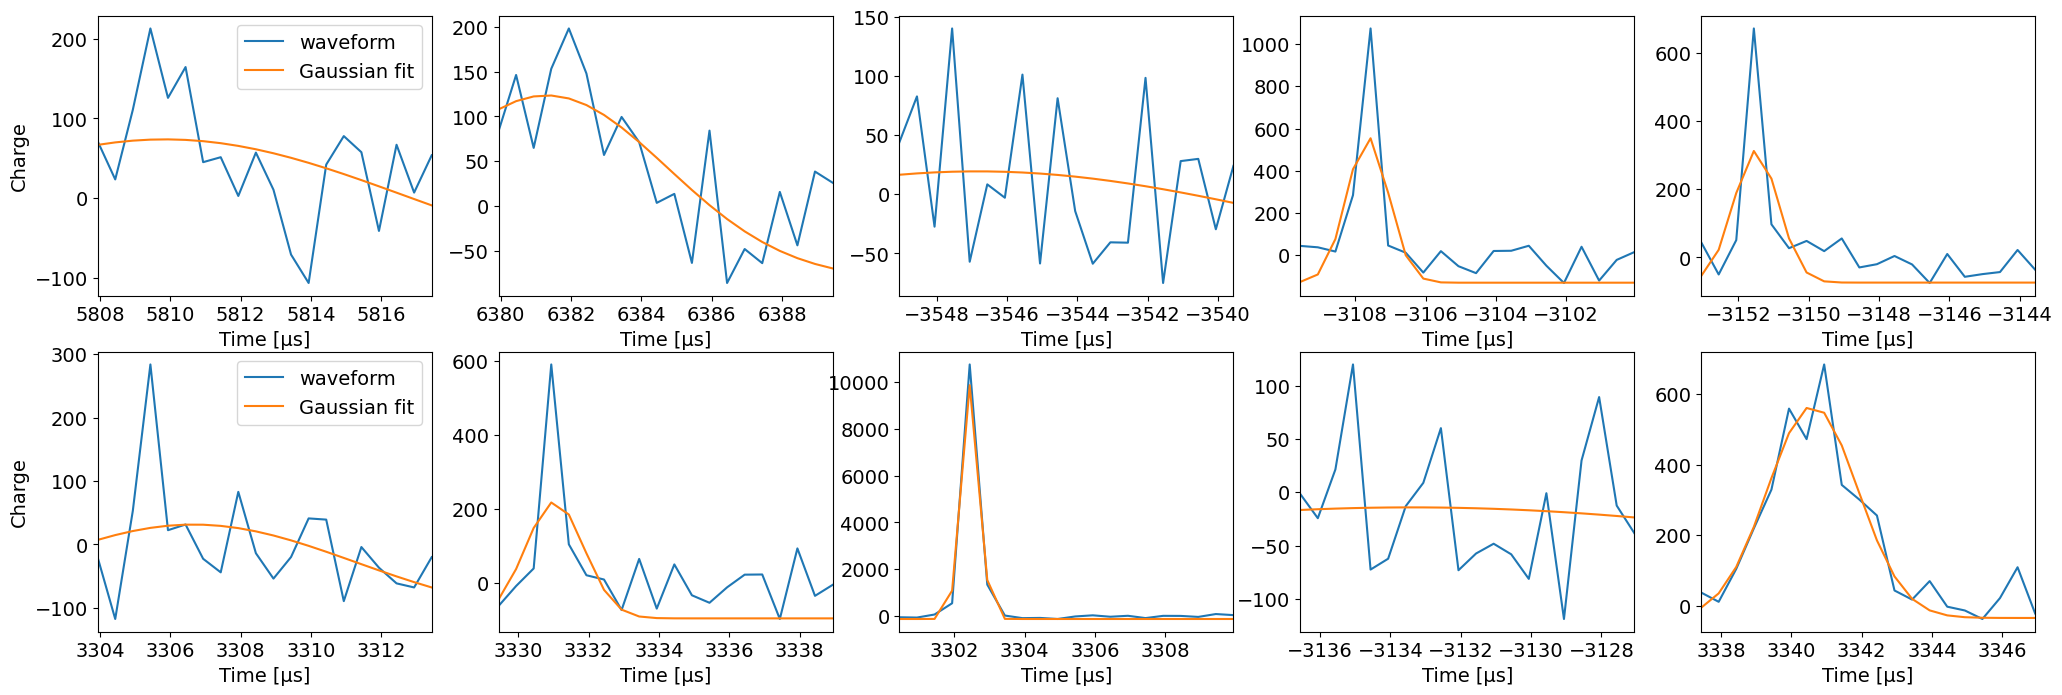

In [12]:
fig, ax = plt.subplots(2, 5, figsize = (25, 8))

dtick = 0.5
t = np.arange(20) * dtick
fonts = 14

for i in range(2):
    for j in range(5):
        k = 5*i + j
        ax[i][j].plot(t + dT.loc[k, "trig t"], dT.loc[k, "waveform"], label = 'waveform')
        y = gauss(t, a = dT.loc[k, "fit_offset_amp"], mu = dT.loc[k, "fit_offset_mu"], sigma = dT.loc[k, "fit_offset_sigma"], c = dT.loc[k, "fit_offset_offset"])
        ax[i][j].plot(t + dT.loc[k, "trig t"], y, label = 'Gaussian fit')

        ax[i][j].set_xlabel('Time [µs]', fontsize = fonts)
        ax[i][j].tick_params(axis = "both", labelsize = fonts)
        ax[i][j].set_xlim([dT.loc[k, "trig t"], dT.loc[k, "trig t"]+9.5])

    ax[i][0].set_ylabel('Charge', fontsize = fonts)
    ax[i][0].legend(fontsize = fonts)


In [13]:
dT['fit_offset_charge'] = dT['fit_offset_amp']*dT['fit_offset_sigma']*np.sqrt(2*np.pi)

In [14]:
dT['fit_offset_rel_diff'] = (dT['fit_offset_charge']-0.5*dT['charge'])*2/dT['charge']
dT['fit_offset_rel_diff'].min(), dT['fit_offset_rel_diff'].max()

(-2127937.5058781044, 257723.65996813148)

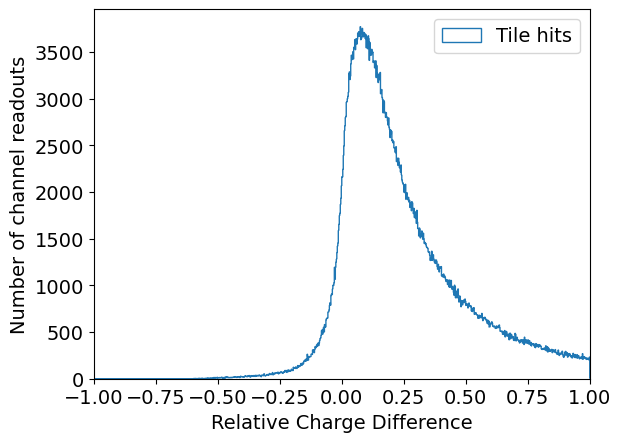

In [15]:
fig, ax = plt.subplots()

tBins = np.linspace(-1, 1, 1001)
fonts = 14

ax.hist(dT['fit_offset_rel_diff'], bins = tBins, histtype = 'step', label = 'Tile hits')
# ax.set_yscale('log')
ax.set_xlim([-1, 1])

ax.set_xlabel('Relative Charge Difference', fontsize = fonts)
ax.set_ylabel('Number of channel readouts', fontsize = fonts)
ax.tick_params(axis = "both", labelsize = fonts)
ax.legend(fontsize = fonts)

In [16]:
noise = 50
err_sum = np.sqrt(20*noise)

In [17]:
dT['fit_offset_pull'] = (dT['fit_offset_charge']-0.5*dT['charge'])/err_sum
dT['fit_offset_pull'].min(), dT['fit_offset_pull'].max()

(-452.69101063810973, 1109.175382209433)

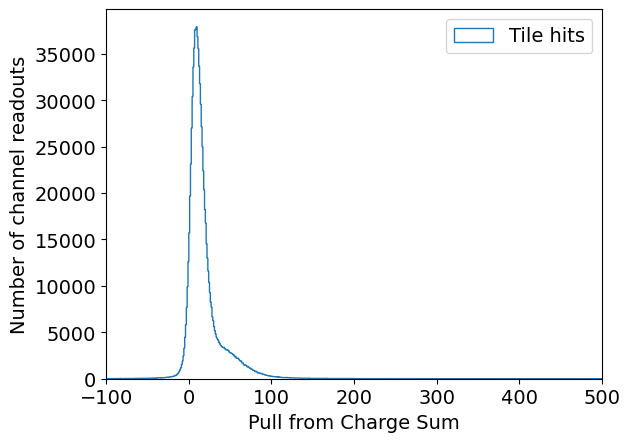

In [18]:
fig, ax = plt.subplots()

tBins = np.linspace(-100, 500, 601)
fonts = 14

ax.hist(dT['fit_offset_pull'], bins = tBins, histtype = 'step', label = 'Tile hits')
# ax.set_yscale('log')
ax.set_xlim([-100, 500])

ax.set_xlabel('Pull from Charge Sum', fontsize = fonts)
ax.set_ylabel('Number of channel readouts', fontsize = fonts)
ax.tick_params(axis = "both", labelsize = fonts)
ax.legend(fontsize = fonts)

## Fit Gaussian with a fixed baseline

In [19]:
def torch_gaussian_fit_no_offset(
    df,
    col = "values",
    batch_size = 50000,
    n_steps = 300,
    lr = 0.05,
    device = None,
    x_spacing = 0.5
):
    """
    Batch Gaussian fitting on GPU/CPU using PyTorch, without an offset term.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame containing a column of lists/arrays of equal length.
    col : str
        Column name containing the y-values.
    batch_size : int
        Number of rows to fit per batch.
    n_steps : int
        Number of optimization steps per batch.
    lr : float
        Learning rate for Adam.
    device : str or None
        "cuda", "cpu", or None to auto-detect.
    x_spacing : float
        Spacing between x-points. For 20 points and x_spacing=0.5,
        x = [0.0, 0.5, ..., 9.5]

    Returns
    -------
    pandas.DataFrame
        Columns: amp, mu, sigma, rmse
    """
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    # Shape: (N, M)
    Y_all = np.stack(df[col].to_numpy()).astype(np.float32)
    N, M = Y_all.shape

    # x-grid
    x = (torch.arange(M, dtype = torch.float32, device = device) * x_spacing)[None, :]
    x_max = float((M - 1) * x_spacing)

    amp_all = np.empty(N, dtype = np.float32)
    mu_all = np.empty(N, dtype = np.float32)
    sigma_all = np.empty(N, dtype = np.float32)
    rmse_all = np.empty(N, dtype = np.float32)

    for start in range(0, N, batch_size):
        end = min(start + batch_size, N)
        Y_np = Y_all[start:end]
        Y = torch.tensor(Y_np, device = device)   # shape (B, M)

        # ----------------------------
        # Initialization
        # ----------------------------
        # If no offset is fitted, assume y >= 0 is ideal.
        # Clamp negatives for moment initialization only.
        Y0 = torch.clamp(Y, min = 0.0)
        wsum = Y0.sum(dim = 1)

        valid = wsum > 1e-8

        amp0 = Y0.max(dim = 1).values
        mu0 = torch.full((Y.shape[0],), x_max / 2, device = device)
        sigma0 = torch.full((Y.shape[0],), max(x_spacing * 2, 1e-3), device = device)

        if valid.any():
            mu0[valid] = (Y0[valid] * x).sum(dim = 1) / wsum[valid]
            var0 = (Y0[valid] * (x - mu0[valid, None]) ** 2).sum(dim = 1) / wsum[valid]
            sigma0[valid] = torch.sqrt(torch.clamp(var0, min = 1e-6))

        amp0 = torch.clamp(amp0, min = 1e-6)
        sigma0 = torch.clamp(sigma0, min = 1e-6)

        # Optimize in unconstrained space for amp and sigma
        log_amp = torch.log(amp0).detach().clone().requires_grad_(True)
        mu = mu0.detach().clone().requires_grad_(True)
        log_sigma = torch.log(sigma0).detach().clone().requires_grad_(True)

        optimizer = torch.optim.Adam([log_amp, mu, log_sigma], lr = lr)

        # ----------------------------
        # Optimization
        # ----------------------------
        for _ in range(n_steps):
            optimizer.zero_grad()

            amp = torch.exp(log_amp)[:, None]        # shape (B, 1)
            sigma = torch.exp(log_sigma)[:, None]    # shape (B, 1)
            mu_b = mu[:, None]                       # shape (B, 1)

            Yhat = amp * torch.exp(-0.5 * ((x - mu_b) / sigma) ** 2)
            loss = ((Yhat - Y) ** 2).mean()

            loss.backward()
            optimizer.step()

            # keep mu in x-range
            with torch.no_grad():
                mu.clamp_(0.0, x_max)

        # ----------------------------
        # Save results
        # ----------------------------
        with torch.no_grad():
            amp_f = torch.exp(log_amp)
            sigma_f = torch.exp(log_sigma)

            Yhat = amp_f[:, None] * torch.exp(-0.5 * ((x - mu[:, None]) / sigma_f[:, None]) ** 2)
            rmse = torch.sqrt(((Yhat - Y) ** 2).mean(dim = 1))

            amp_all[start:end] = amp_f.cpu().numpy()
            mu_all[start:end] = mu.cpu().numpy()
            sigma_all[start:end] = sigma_f.cpu().numpy()
            rmse_all[start:end] = rmse.cpu().numpy()

        print(f"Processed rows {start:,} to {end:,} / {N:,}")

    result = pd.DataFrame({
        "amp": amp_all,
        "mu": mu_all,
        "sigma": sigma_all,
        "rmse": rmse_all,
    }, index = df.index)

    return result

### Tile waveforms

In [20]:
fit_torch = torch_gaussian_fit_no_offset(
    df = dT,
    col = "waveform",
    batch_size = 20000,
    n_steps = 200,
    lr = 0.03,
    x_spacing = 0.5
)

dT = pd.concat([dT, fit_torch.add_prefix("fit_")], axis = 1)

Processed rows 0 to 20,000 / 888,947
Processed rows 20,000 to 40,000 / 888,947
Processed rows 40,000 to 60,000 / 888,947
Processed rows 60,000 to 80,000 / 888,947
Processed rows 80,000 to 100,000 / 888,947
Processed rows 100,000 to 120,000 / 888,947
Processed rows 120,000 to 140,000 / 888,947
Processed rows 140,000 to 160,000 / 888,947
Processed rows 160,000 to 180,000 / 888,947
Processed rows 180,000 to 200,000 / 888,947
Processed rows 200,000 to 220,000 / 888,947
Processed rows 220,000 to 240,000 / 888,947
Processed rows 240,000 to 260,000 / 888,947
Processed rows 260,000 to 280,000 / 888,947
Processed rows 280,000 to 300,000 / 888,947
Processed rows 300,000 to 320,000 / 888,947
Processed rows 320,000 to 340,000 / 888,947
Processed rows 340,000 to 360,000 / 888,947
Processed rows 360,000 to 380,000 / 888,947
Processed rows 380,000 to 400,000 / 888,947
Processed rows 400,000 to 420,000 / 888,947
Processed rows 420,000 to 440,000 / 888,947
Processed rows 440,000 to 460,000 / 888,947
Pr

In [21]:
def gauss_no_offset(x, a, mu, sigma):
    return a * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

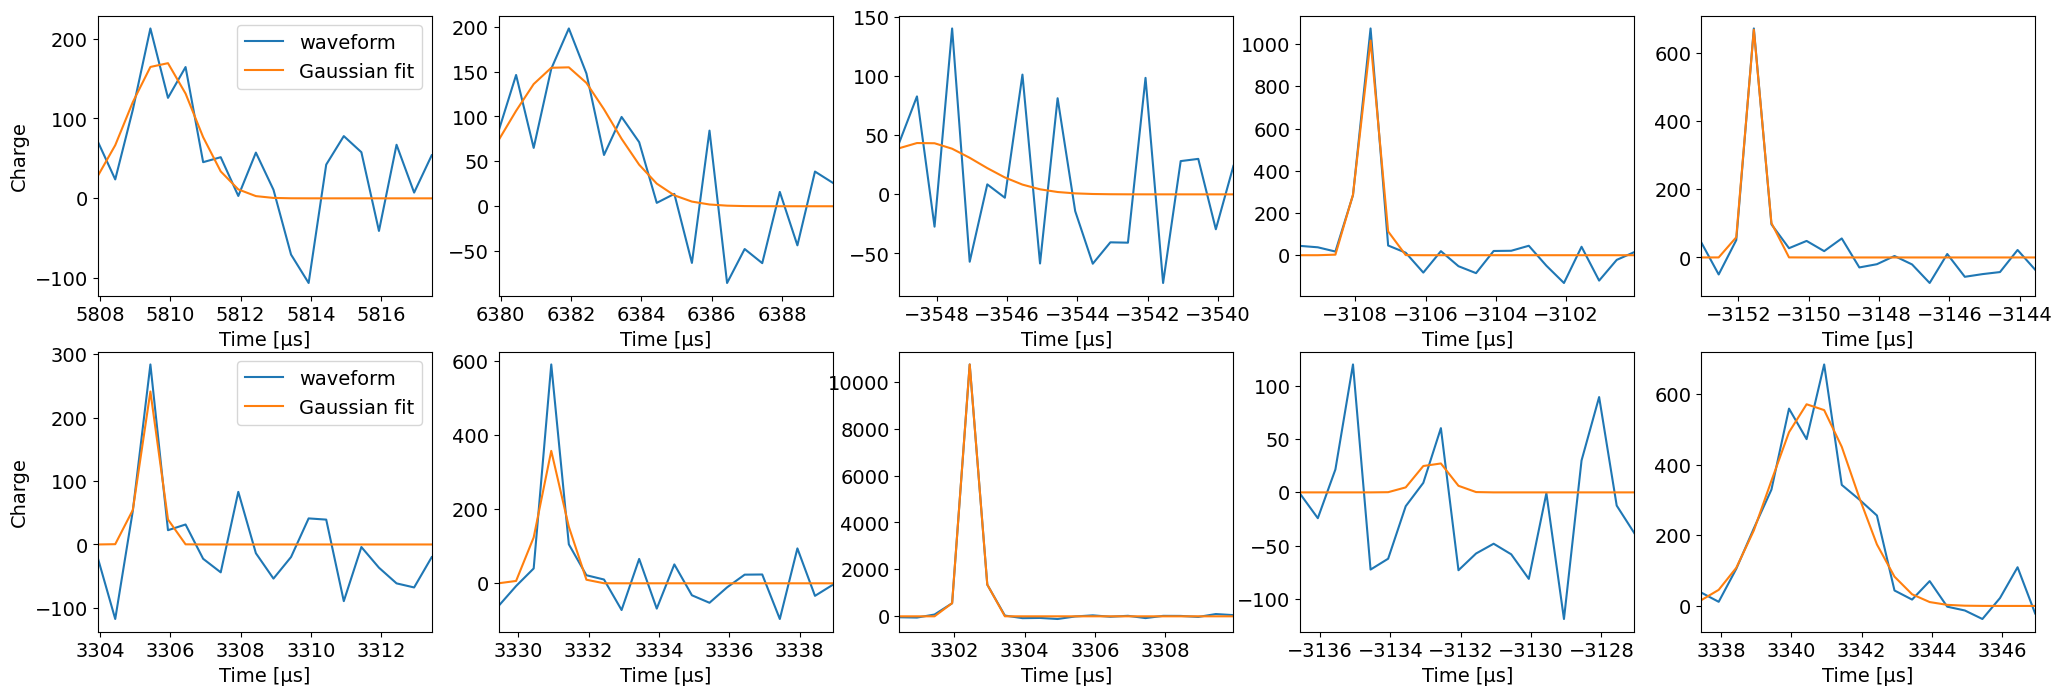

In [22]:
fig, ax = plt.subplots(2, 5, figsize = (25, 8))

dtick = 0.5
t = np.arange(20) * dtick
fonts = 14

for i in range(2):
    for j in range(5):
        k = 5*i + j
        ax[i][j].plot(t + dT.loc[k, "trig t"], dT.loc[k, "waveform"], label = 'waveform')
        y = gauss_no_offset(t, a = dT.loc[k, "fit_amp"], mu = dT.loc[k, "fit_mu"], sigma = dT.loc[k, "fit_sigma"])
        ax[i][j].plot(t + dT.loc[k, "trig t"], y, label = 'Gaussian fit')

        ax[i][j].set_xlabel('Time [µs]', fontsize = fonts)
        ax[i][j].tick_params(axis = "both", labelsize = fonts)
        ax[i][j].set_xlim([dT.loc[k, "trig t"], dT.loc[k, "trig t"]+9.5])

    ax[i][0].set_ylabel('Charge', fontsize = fonts)
    ax[i][0].legend(fontsize = fonts)


In [23]:
dT['fit_charge'] = dT['fit_amp']*dT['fit_sigma']*np.sqrt(2*np.pi)

In [24]:
dT['fit_rel_diff'] = (dT['fit_charge']-0.5*dT['charge'])*2/dT['charge']
dT['fit_rel_diff'].min(), dT['fit_rel_diff'].max()

(-101577.82076796533, 7079.66865954673)

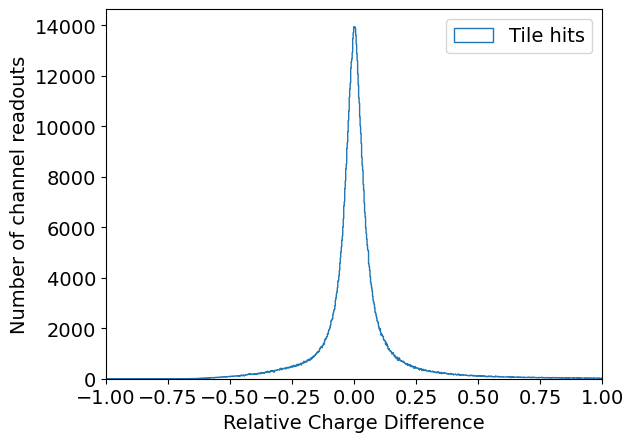

In [25]:
fig, ax = plt.subplots()

tBins = np.linspace(-1, 1, 1001)
fonts = 14

ax.hist(dT['fit_rel_diff'], bins = tBins, histtype = 'step', label = 'Tile hits')
# ax.set_yscale('log')
ax.set_xlim([-1, 1])

ax.set_xlabel('Relative Charge Difference', fontsize = fonts)
ax.set_ylabel('Number of channel readouts', fontsize = fonts)
ax.tick_params(axis = "both", labelsize = fonts)
ax.legend(fontsize = fonts)

#### Pull distribution

In [26]:
dT['fit_pull'] = (dT['fit_charge']-0.5*dT['charge'])/err_sum
dT['fit_pull'].min(), dT['fit_pull'].max()

(-586.3914379504321, 770.3243657019016)

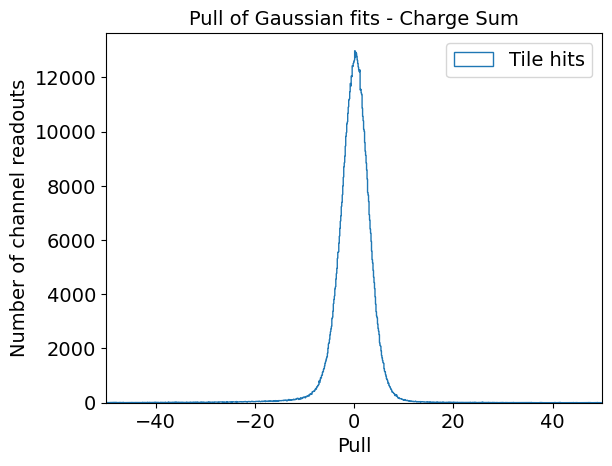

In [27]:
fig, ax = plt.subplots()

tBins = np.linspace(-50, 50, 1001)
fonts = 14

ax.hist(dT['fit_pull'], bins = tBins, histtype = 'step', label = 'Tile hits')
# ax.set_yscale('log')
ax.set_xlim([-50, 50])

ax.set_title('Pull of Gaussian fits - Charge Sum', fontsize = fonts)
ax.set_xlabel('Pull', fontsize = fonts)
ax.set_ylabel('Number of channel readouts', fontsize = fonts)
ax.tick_params(axis = "both", labelsize = fonts)
ax.legend(fontsize = fonts)

In [28]:
from scipy.optimize import curve_fit

In [29]:
fit_pull = dT['fit_pull'].dropna().to_numpy()
counts, edges = np.histogram(fit_pull, bins = 2000, range = (-50, 50))
centers = 0.5 * (edges[:-1] + edges[1:])
# Initial guesses
p0 = [counts.max(), np.mean(fit_pull), np.std(fit_pull)]

# Fit Gaussian to histogram counts
params, covariance = curve_fit(gauss_no_offset, centers, counts, p0 = p0)
pull_A, pull_mu, pull_sigma = params
pull_A, pull_mu, pull_sigma

(np.float64(6251.170371353745),
 np.float64(0.19487727273038946),
 np.float64(2.7133713009237455))

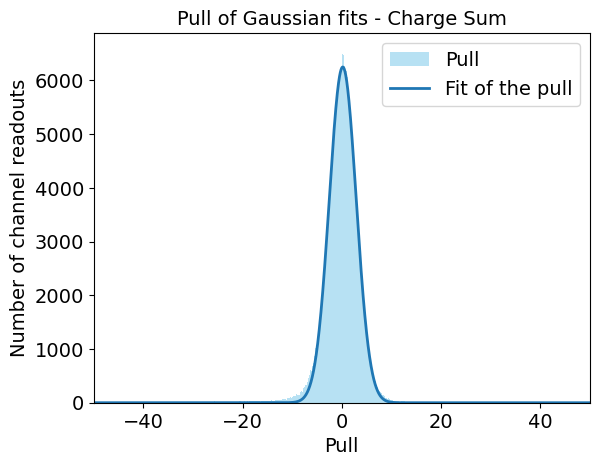

In [30]:
fig, ax = plt.subplots()

pBins = np.linspace(-50, 50, 2001)
fonts = 14

ax.hist(dT['fit_pull'], bins = pBins, alpha = 0.6, color = "skyblue", label = 'Pull')
ax.plot(pBins, gauss_no_offset(pBins, pull_A, pull_mu, pull_sigma), lw = 2, label = 'Fit of the pull')

# ax.set_yscale('log')
ax.set_xlim([-50, 50])

ax.set_title('Pull of Gaussian fits - Charge Sum', fontsize = fonts)
ax.set_xlabel('Pull', fontsize = fonts)
ax.set_ylabel('Number of channel readouts', fontsize = fonts)
ax.tick_params(axis = "both", labelsize = fonts)
ax.legend(fontsize = fonts)

### Pixel waveforms

In [31]:
fit_torch = torch_gaussian_fit_no_offset(
    df = dP,
    col = "waveform",
    batch_size = 20000,
    n_steps = 200,
    lr = 0.03,
    x_spacing = 0.5
)

dP = pd.concat([dP, fit_torch.add_prefix("fit_")], axis = 1)

Processed rows 0 to 20,000 / 3,141,162
Processed rows 20,000 to 40,000 / 3,141,162
Processed rows 40,000 to 60,000 / 3,141,162
Processed rows 60,000 to 80,000 / 3,141,162
Processed rows 80,000 to 100,000 / 3,141,162
Processed rows 100,000 to 120,000 / 3,141,162
Processed rows 120,000 to 140,000 / 3,141,162
Processed rows 140,000 to 160,000 / 3,141,162
Processed rows 160,000 to 180,000 / 3,141,162
Processed rows 180,000 to 200,000 / 3,141,162
Processed rows 200,000 to 220,000 / 3,141,162
Processed rows 220,000 to 240,000 / 3,141,162
Processed rows 240,000 to 260,000 / 3,141,162
Processed rows 260,000 to 280,000 / 3,141,162
Processed rows 280,000 to 300,000 / 3,141,162
Processed rows 300,000 to 320,000 / 3,141,162
Processed rows 320,000 to 340,000 / 3,141,162
Processed rows 340,000 to 360,000 / 3,141,162
Processed rows 360,000 to 380,000 / 3,141,162
Processed rows 380,000 to 400,000 / 3,141,162
Processed rows 400,000 to 420,000 / 3,141,162
Processed rows 420,000 to 440,000 / 3,141,162
Pr

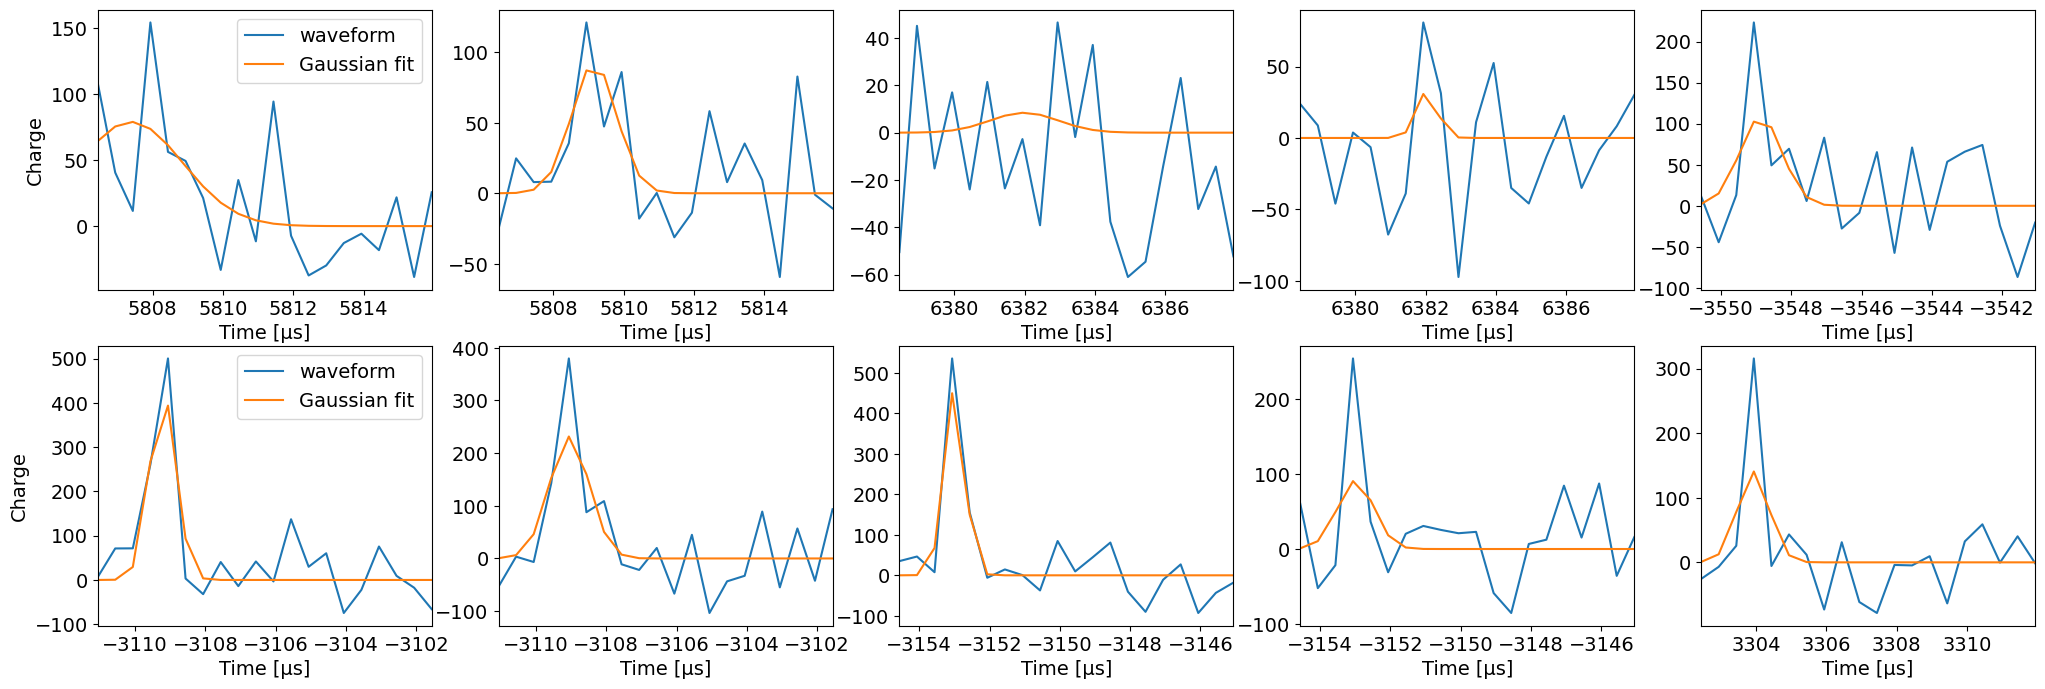

In [32]:
fig, ax = plt.subplots(2, 5, figsize = (25, 8))

dtick = 0.5
t = np.arange(20) * dtick
fonts = 14

for i in range(2):
    for j in range(5):
        k = 5*i + j
        ax[i][j].plot(t + dP.loc[k, "trig t"], dP.loc[k, "waveform"], label = 'waveform')
        y = gauss_no_offset(t, a = dP.loc[k, "fit_amp"], mu = dP.loc[k, "fit_mu"], sigma = dP.loc[k, "fit_sigma"])
        ax[i][j].plot(t + dP.loc[k, "trig t"], y, label = 'Gaussian fit')

        ax[i][j].set_xlabel('Time [µs]', fontsize = fonts)
        ax[i][j].tick_params(axis = "both", labelsize = fonts)
        ax[i][j].set_xlim([dP.loc[k, "trig t"], dP.loc[k, "trig t"]+9.5])

    ax[i][0].set_ylabel('Charge', fontsize = fonts)
    ax[i][0].legend(fontsize = fonts)


In [33]:
dP['fit_charge'] = dP['fit_amp']*dP['fit_sigma']*np.sqrt(2*np.pi)

In [34]:
dP['fit_rel_diff'] = (dP['fit_charge']-0.5*dP['charge'])*2/dP['charge']
dP['fit_rel_diff'].min(), dP['fit_rel_diff'].max()

(-378450.4324437883, 1356739.3404965713)

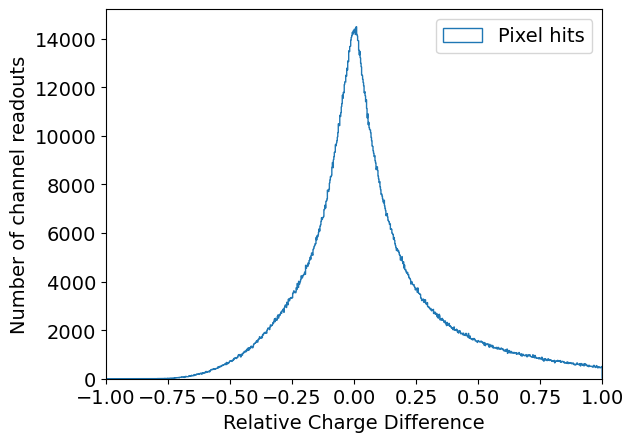

In [35]:
fig, ax = plt.subplots()

tBins = np.linspace(-1, 1, 1001)
fonts = 14

ax.hist(dP['fit_rel_diff'], bins = tBins, histtype = 'step', label = 'Pixel hits')
# ax.set_yscale('log')
ax.set_xlim([-1, 1])

ax.set_xlabel('Relative Charge Difference', fontsize = fonts)
ax.set_ylabel('Number of channel readouts', fontsize = fonts)
ax.tick_params(axis = "both", labelsize = fonts)
ax.legend(fontsize = fonts)

#### Pull distribution

In [36]:
dP['fit_pull'] = (dP['fit_charge']-0.5*dP['charge'])/err_sum
dP['fit_pull'].min(), dP['fit_pull'].max()

(-443.1925271871314, 704.9214438865164)

In [37]:
p_fit_pull = dP['fit_pull'].dropna().to_numpy()
counts, edges = np.histogram(p_fit_pull, bins = 2000, range = (-50, 50))
centers = 0.5 * (edges[:-1] + edges[1:])
# Initial guesses
p0 = [counts.max(), np.mean(p_fit_pull), np.std(p_fit_pull)]

# Fit Gaussian to histogram counts
params, covariance = curve_fit(gauss_no_offset, centers, counts, p0 = p0)
pull_A, pull_mu, pull_sigma = params
pull_A, pull_mu, pull_sigma

(np.float64(25288.616398593473),
 np.float64(0.6760128776296865),
 np.float64(2.401629405837485))

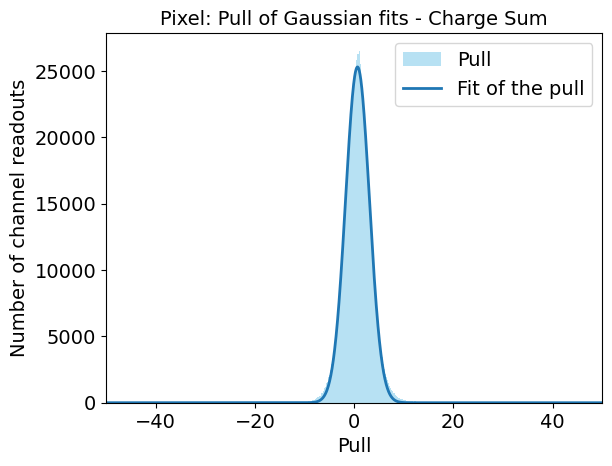

In [38]:
fig, ax = plt.subplots()

pBins = np.linspace(-50, 50, 2001)
fonts = 14

ax.hist(dP['fit_pull'], bins = pBins, alpha = 0.6, color = "skyblue", label = 'Pull')
ax.plot(pBins, gauss_no_offset(pBins, pull_A, pull_mu, pull_sigma), lw = 2, label = 'Fit of the pull')

# ax.set_yscale('log')
ax.set_xlim([-50, 50])

ax.set_title('Pixel: Pull of Gaussian fits - Charge Sum', fontsize = fonts)
ax.set_xlabel('Pull', fontsize = fonts)
ax.set_ylabel('Number of channel readouts', fontsize = fonts)
ax.tick_params(axis = "both", labelsize = fonts)
ax.legend(fontsize = fonts)

In [39]:
dP['fit_charge'].min(), dP['fit_charge'].max()

(0.1382831638833947, 49879.57717994118)

In [40]:
noise = 50
threshold = 3*noise

In [41]:
import math

In [42]:
dP['n_fit_sigma'] = -2*np.log(threshold/dP['fit_amp'])

In [43]:
def unnormalized_gaussian_integral(n, A, sigma):
    return A * sigma * math.sqrt(2 * math.pi) * math.erf(n / math.sqrt(2))

In [44]:
dP['fit_3sd_charge'] = dP.apply(
    lambda row: 0 if row['n_fit_sigma'] <= 0
    else unnormalized_gaussian_integral(row['n_fit_sigma'], row['fit_amp'], row['fit_sigma']),
    axis = 1
)

In [45]:
dP['fit_3sd_charge'].min(), dP['fit_3sd_charge'].max()

(0.0, 49879.57795517513)

In [46]:
dP['fit_amp'].min(), dP['fit_amp'].max()

(3.1420226097106934, 56818.5703125)

In [47]:
np.log(2)

np.float64(0.6931471805599453)